# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 90.7 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [6]:
dataframes = {
    "Income": df_hh_income,
    "Poverty": df_pct_poverty,
    "High School": df_pct_completed_hs,
    "Race": df_share_race_city,
    "Fatalities": df_fatalities
}

In [7]:
for name, df in dataframes.items():
    print(f"Database name: {name}")
    print(f"Shape: {df.shape}")
    print(f"Column Names: {list(df.columns)}")
    print(f"Total NaN values: {df.isna().sum().sum()}")
    print(f"Total Duplicate rows: {df.duplicated().sum()}")
    print("\n")

Database name: Income
Shape: (29322, 3)
Column Names: ['Geographic Area', 'City', 'Median Income']
Total NaN values: 51
Total Duplicate rows: 0


Database name: Poverty
Shape: (29329, 3)
Column Names: ['Geographic Area', 'City', 'poverty_rate']
Total NaN values: 0
Total Duplicate rows: 0


Database name: High School
Shape: (29329, 3)
Column Names: ['Geographic Area', 'City', 'percent_completed_hs']
Total NaN values: 0
Total Duplicate rows: 0


Database name: Race
Shape: (29268, 7)
Column Names: ['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
Total NaN values: 0
Total Duplicate rows: 0


Database name: Fatalities
Shape: (2535, 14)
Column Names: ['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']
Total NaN values: 346
Total Duplicate rows: 0




## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [14]:
for df in dataframes.values():
    df.drop_duplicates(inplace=True)
    df.fillna(0, inplace=True)

In [15]:
for name, df in dataframes.items():
    print(f"Database name: {name}")
    print(f"Shape: {df.shape}")
    print(f"Column Names: {list(df.columns)}")
    print(f"Total NaN values: {df.isna().sum().sum()}")
    print(f"Total Duplicate rows: {df.duplicated().sum()}")
    print("\n")

Database name: Income
Shape: (29322, 3)
Column Names: ['Geographic Area', 'City', 'Median Income']
Total NaN values: 0
Total Duplicate rows: 0


Database name: Poverty
Shape: (29329, 3)
Column Names: ['Geographic Area', 'City', 'poverty_rate']
Total NaN values: 0
Total Duplicate rows: 0


Database name: High School
Shape: (29329, 3)
Column Names: ['Geographic Area', 'City', 'percent_completed_hs']
Total NaN values: 0
Total Duplicate rows: 0


Database name: Race
Shape: (29268, 7)
Column Names: ['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
Total NaN values: 0
Total Duplicate rows: 0


Database name: Fatalities
Shape: (2535, 14)
Column Names: ['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']
Total NaN values: 0
Total Duplicate rows: 0




# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

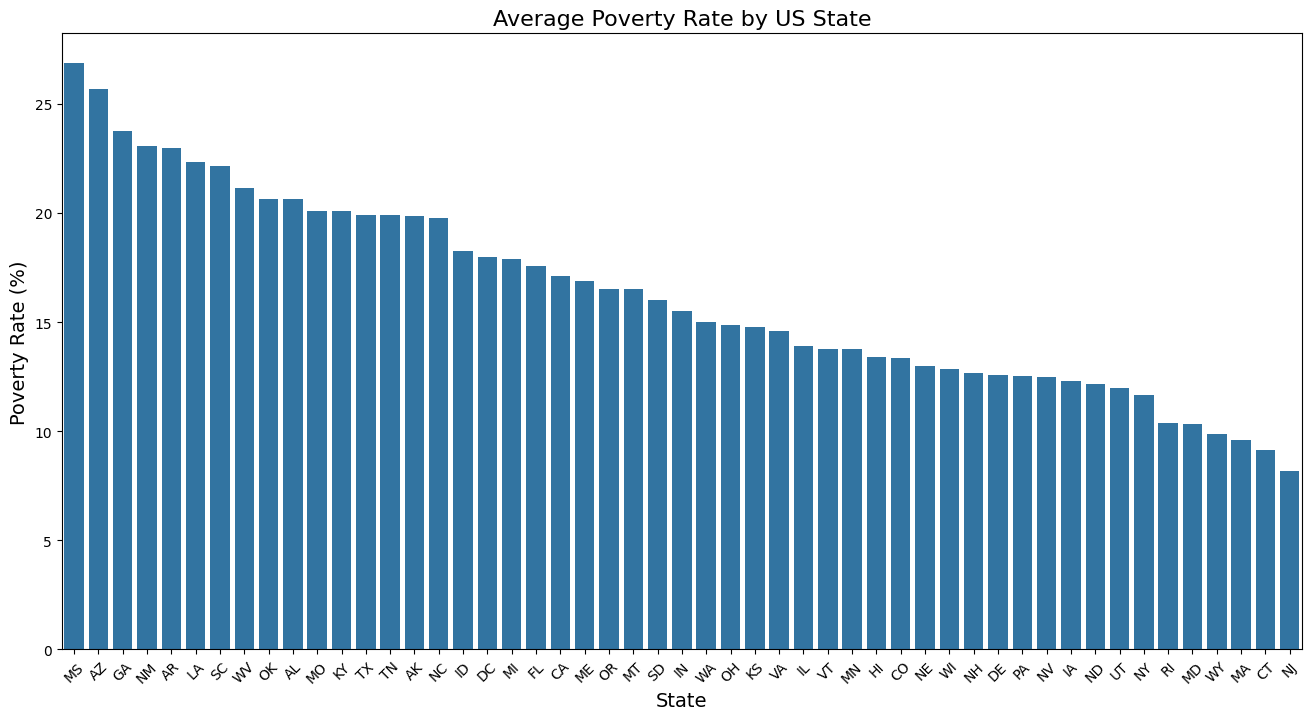

State with the highest poverty rate is MS with 26.88%
State with the lowest poverty rate is NJ with 8.19%


In [23]:
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')

df_poverty_rate_by_state = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
df_poverty_rate_by_state = df_poverty_rate_by_state.sort_values(by='poverty_rate', ascending=False)

plt.figure(figsize=(16, 8))
sns.barplot(x='Geographic Area', y='poverty_rate', data=df_poverty_rate_by_state)
plt.title('Average Poverty Rate by US State', fontsize=16)
plt.xlabel('State', fontsize=14)
plt.ylabel('Poverty Rate (%)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

highest_state = df_poverty_rate_by_state.iloc[0]
lowest_state = df_poverty_rate_by_state.iloc[-1]

print(f"State with the highest poverty rate is {highest_state['Geographic Area']} with {highest_state['poverty_rate']:.2f}%")
print(f"State with the lowest poverty rate is {lowest_state['Geographic Area']} with {lowest_state['poverty_rate']:.2f}%")

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

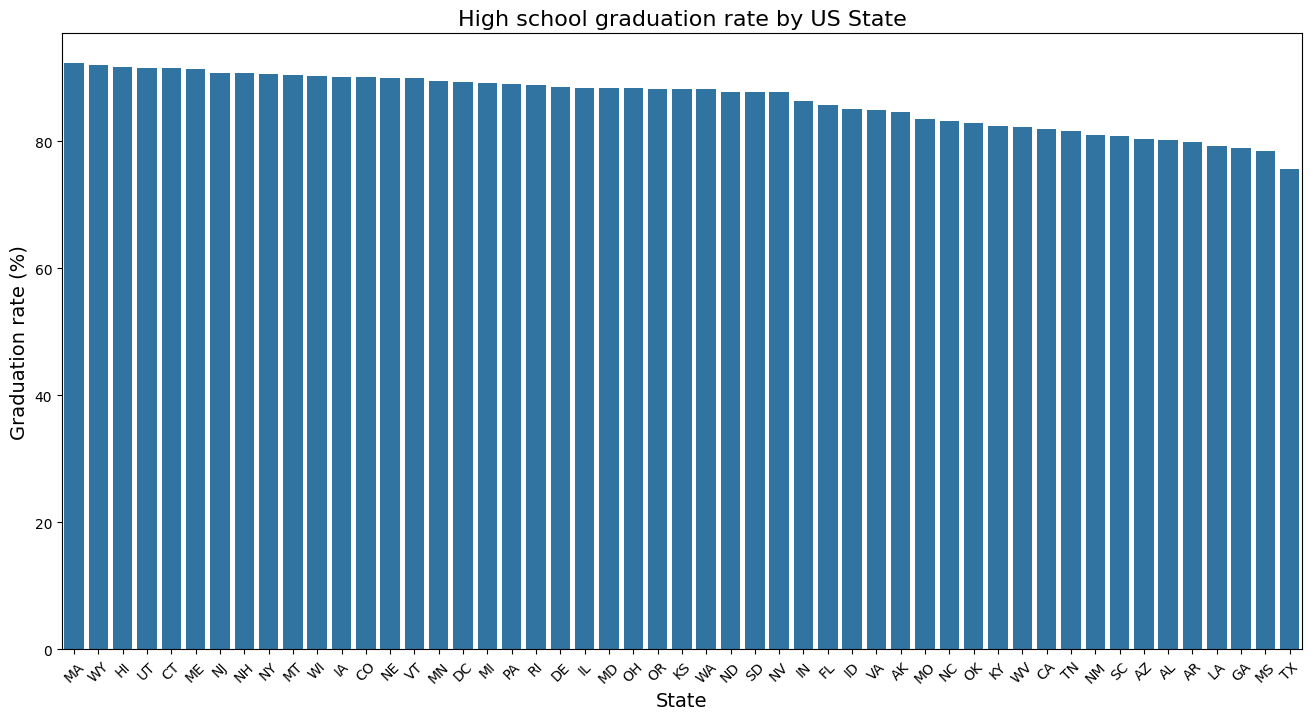

Highest is MA with 92.40%
Lowest is TX with 75.69%


In [24]:
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')

df_completed_hs_by_state = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().reset_index()
df_completed_hs_by_state = df_completed_hs_by_state.sort_values(by='percent_completed_hs', ascending=False)

plt.figure(figsize=(16, 8))
sns.barplot(x='Geographic Area', y='percent_completed_hs', data=df_completed_hs_by_state)
plt.title('High school graduation rate by US State', fontsize=16)
plt.xlabel('State', fontsize=14)
plt.ylabel('Graduation rate (%)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

highest_state = df_completed_hs_by_state.iloc[0]
lowest_state = df_completed_hs_by_state.iloc[-1]

print(f"Highest is {highest_state['Geographic Area']} with {highest_state['percent_completed_hs']:.2f}%")
print(f"Lowest is {lowest_state['Geographic Area']} with {lowest_state['percent_completed_hs']:.2f}%")

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

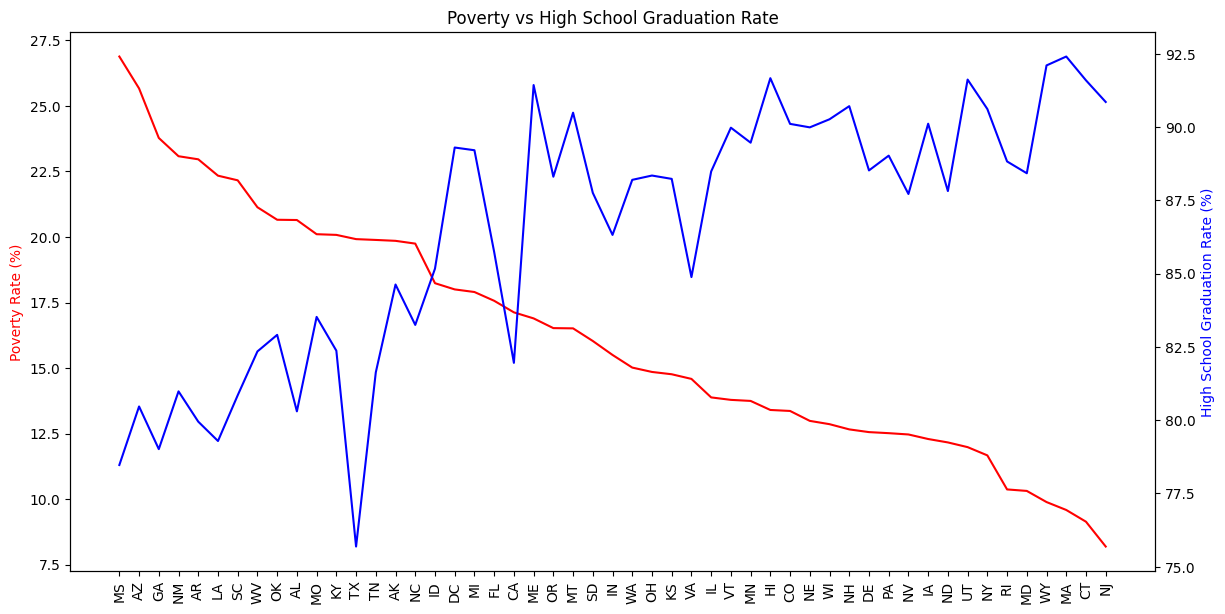

In [31]:
df_merged_poverty_graduation = pd.merge(df_poverty_rate_by_state, df_completed_hs_by_state, on='Geographic Area')

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(df_merged_poverty_graduation['Geographic Area'], df_merged_poverty_graduation['poverty_rate'], color='red')
ax1.set_ylabel('Poverty Rate (%)', color='red')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(df_merged_poverty_graduation['Geographic Area'], df_merged_poverty_graduation['percent_completed_hs'], color='blue')
ax2.set_ylabel('High School Graduation Rate (%)', color='blue')

plt.title('Poverty vs High School Graduation Rate')
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

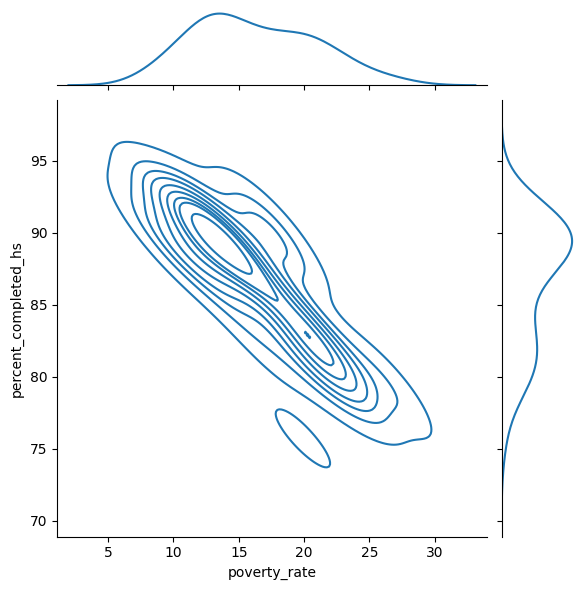

In [33]:
sns.jointplot(x='poverty_rate', y='percent_completed_hs', data=df_merged_poverty_graduation, kind='kde')
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

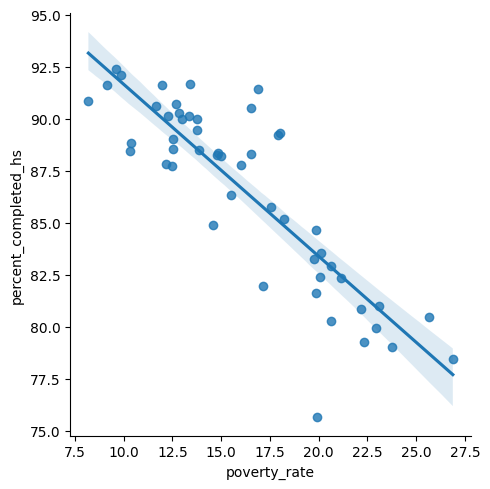

In [35]:
sns.lmplot(x='poverty_rate', y='percent_completed_hs', data=df_merged_poverty_graduation)
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

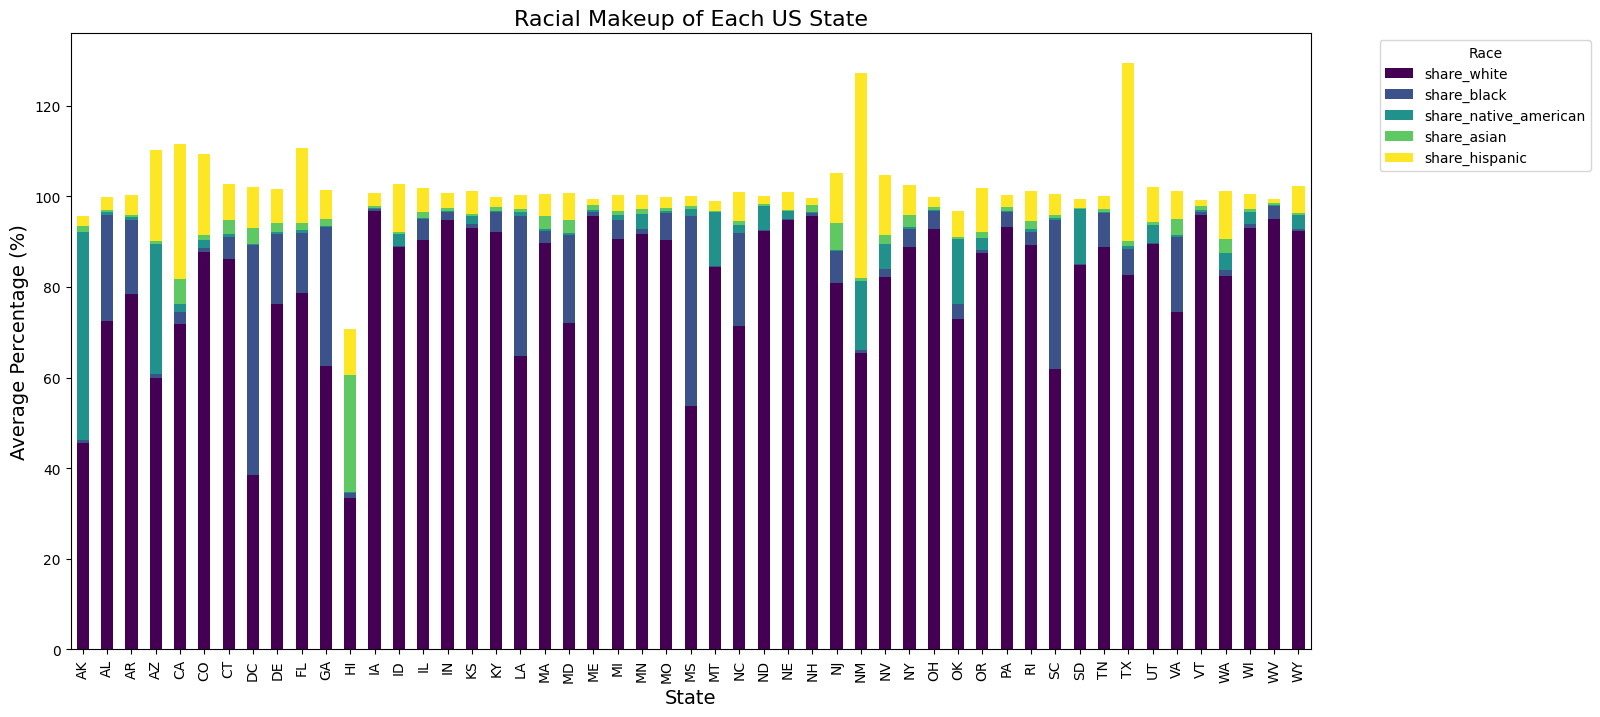

In [36]:
race_columns = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']

for col in race_columns:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')

df_race_by_state = df_share_race_city.groupby('Geographic area')[race_columns].mean()

df_race_by_state.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='viridis')

plt.title('Racial Makeup of Each US State', fontsize=16)
plt.xlabel('State', fontsize=14)
plt.ylabel('Average Percentage (%)', fontsize=14)

plt.legend(title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [40]:
df_killes_race_counts = df_fatalities['race'].value_counts()

fig = px.pie(values=df_killes_race_counts.values, names=df_killes_race_counts.index, title='People Killed by Police by Race', hole=0.4)
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

Men killed: 2428
Women killed: 107


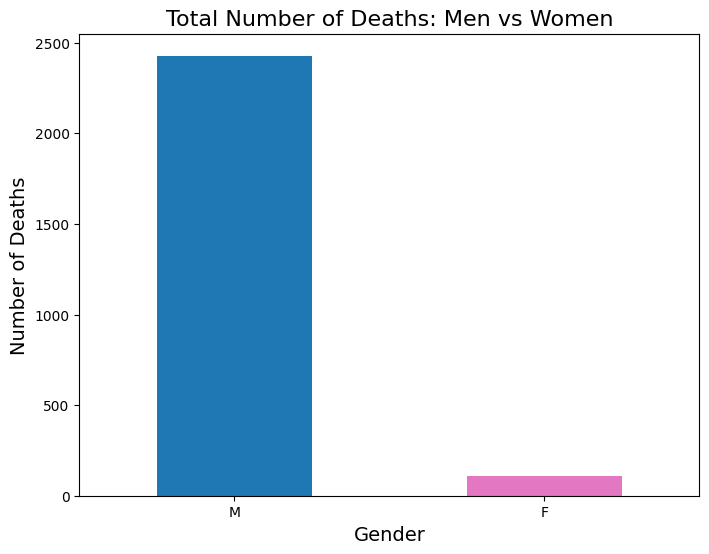

In [41]:
df_killed_gender_counts = df_fatalities['gender'].value_counts()

difference = df_killed_gender_counts['M'] - df_killed_gender_counts['F']
print(f"Men killed: {df_killed_gender_counts['M']}")
print(f"Women killed: {df_killed_gender_counts['F']}")

df_killed_gender_counts.plot(kind='bar', figsize=(8, 6), color=['#1f77b4', '#e377c2'])

plt.title('Total Number of Deaths: Men vs Women', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Number of Deaths', fontsize=14)
plt.xticks(rotation=0)
plt.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

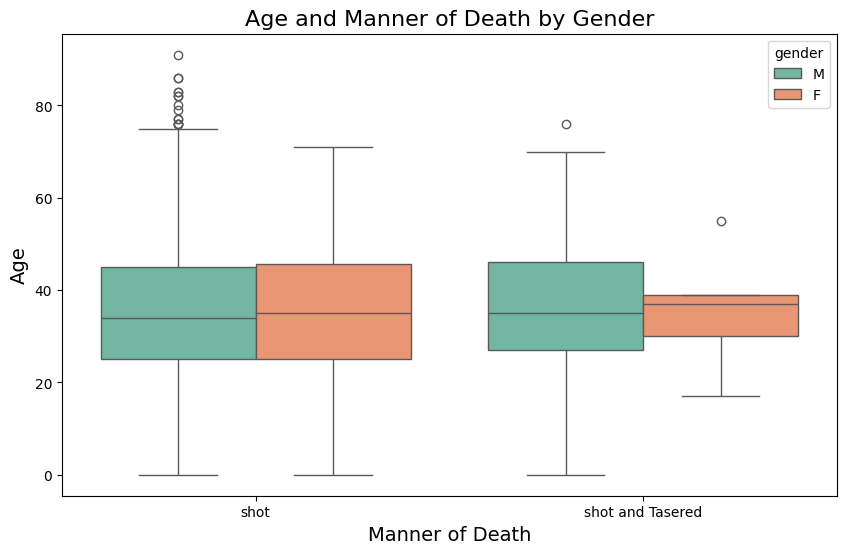

In [42]:
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fatalities, x='manner_of_death', y='age', hue='gender', palette='Set2')

plt.title('Age and Manner of Death by Gender', fontsize=16)
plt.xlabel('Manner of Death', fontsize=14)
plt.ylabel('Age', fontsize=14)
plt.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

Percentage of people armed (including undetermined): 93.25%
People armed with a gun: 1398
People who were unarmed: 171


/tmp/ipykernel_648/523449795.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_weapon_counts[:15].index, y=df_weapon_counts[:15].values, palette='magma')


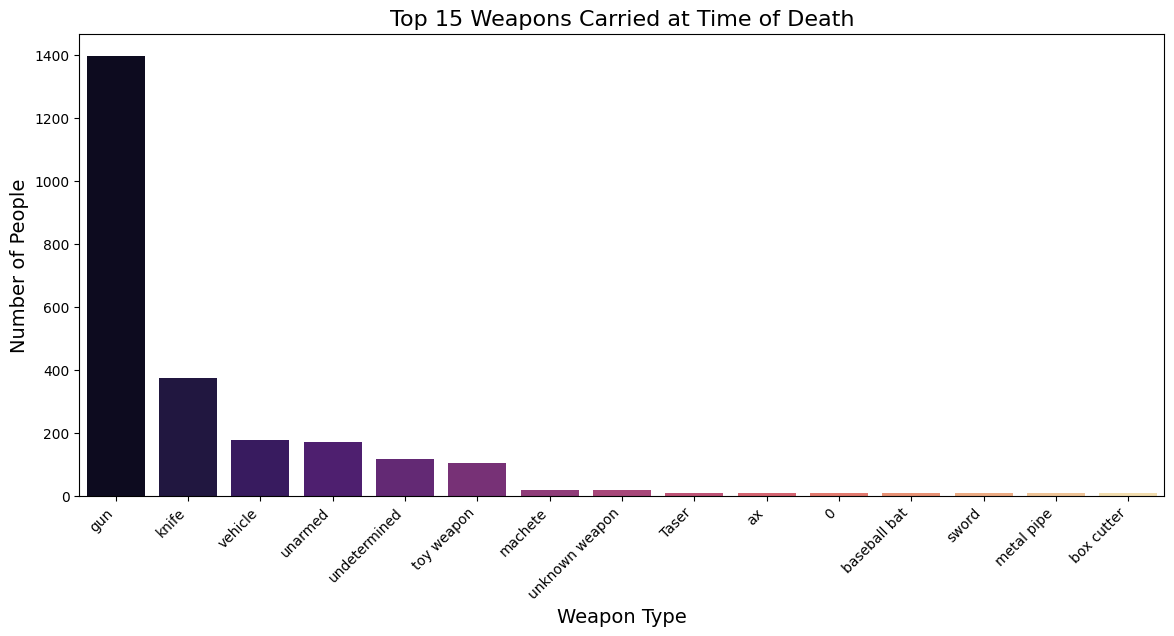

In [43]:
df_weapon_counts = df_fatalities['armed'].value_counts()

df_unarmed_count = df_weapon_counts.get('unarmed', 0)
df_gun_count = df_weapon_counts.get('gun', 0)
df_total_people = len(df_fatalities)

armed_percentage = ((df_total_people - df_unarmed_count) / df_total_people) * 100

print(f"Percentage of people armed (including undetermined): {armed_percentage:.2f}%")
print(f"People armed with a gun: {df_gun_count}")
print(f"People who were unarmed: {df_unarmed_count}")

plt.figure(figsize=(14, 6))
sns.barplot(x=df_weapon_counts[:15].index, y=df_weapon_counts[:15].values, palette='magma')

plt.title('Top 15 Weapons Carried at Time of Death', fontsize=16)
plt.xlabel('Weapon Type', fontsize=14)
plt.ylabel('Number of People', fontsize=14)
plt.xticks(rotation=45, ha='right')

plt.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [44]:
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')

df_under_25_count = len(df_fatalities[df_fatalities['age'] < 25])

total_fatalities = len(df_fatalities)
percent_under_25 = (df_under_25_count / total_fatalities) * 100

print(f"Percentage of people killed under 25 years old: {percent_under_25:.2f}%")

Percentage of people killed under 25 years old: 20.79%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

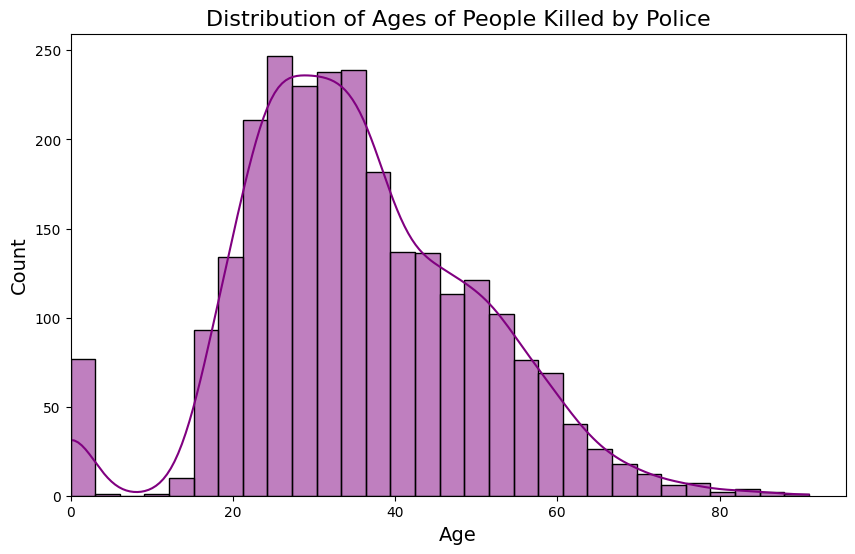

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_fatalities, x='age', kde=True, bins=30, color='purple')

plt.xlim(left=0)

plt.title('Distribution of Ages of People Killed by Police', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions?

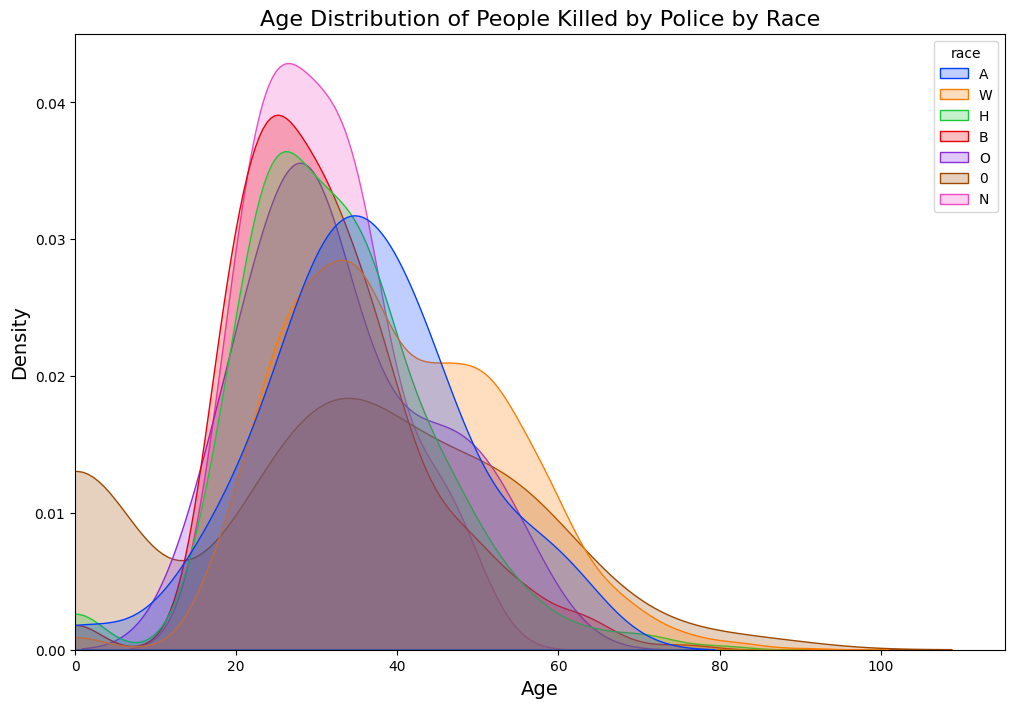

In [47]:
plt.figure(figsize=(12, 8))
sns.kdeplot(data=df_fatalities, x='age', hue='race', fill=True, common_norm=False, palette='bright')

plt.xlim(left=0)

plt.title('Age Distribution of People Killed by Police by Race', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race.

In [48]:
df_killed_race_totals = df_fatalities['race'].value_counts()

fig = px.bar(x=df_killed_race_totals.index,
             y=df_killed_race_totals.values,
             color=df_killed_race_totals.index,
             title='Total Number of People Killed by Race',
             labels={'x': 'Race', 'y': 'Number of Deaths'})
fig.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [49]:
df_mental_illness_counts = df_fatalities['signs_of_mental_illness'].value_counts()

df_total_deaths = len(df_fatalities)
df_mental_illness_pct = (df_mental_illness_counts[True] / df_total_deaths) * 100

print(f"Percentage of victims with signs of mental illness: {df_mental_illness_pct:.2f}%")

fig = px.bar(x=['Signs of Mental Illness', 'No Signs'],
             y=[df_mental_illness_counts[True], df_mental_illness_counts[False]],
             color=['True', 'False'],
             title='Mental Illness Signs in Police Killings',
             labels={'x': 'Status', 'y': 'Number of People'})
fig.show()

Percentage of victims with signs of mental illness: 24.97%


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [51]:
df_killing_top_10_cities = df_fatalities['city'].value_counts().head(10)

fig = px.bar(x=df_killing_top_10_cities.index,
             y=df_killing_top_10_cities.values,
             color=df_killing_top_10_cities.values,
             color_continuous_scale='Reds',
             title='Top 10 Cities with the Most Police Killings',
             labels={'x': 'City', 'y': 'Number of Killings', 'color': 'Count'})
fig.show()

print("The 10 cities with the highest number of police killings are:")
print(df_killing_top_10_cities)

The 10 cities with the highest number of police killings are:
city
Los Angeles    39
Phoenix        31
Houston        27
Chicago        25
Las Vegas      21
San Antonio    20
Columbus       19
Miami          18
Austin         18
St. Louis      15
Name: count, dtype: int64


# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [53]:
df_share_temp = df_share_race_city.copy()

df_share_temp['city_clean'] = df_share_temp['City'].str.replace(' city| town| CDP| village', '', regex=True)

race_columns = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
for col in race_columns:
    df_share_temp[col] = pd.to_numeric(df_share_temp[col], errors='coerce').fillna(0)

top_cities = df_killing_top_10_cities.index

df_top_fatalities = df_fatalities[df_fatalities['city'].isin(top_cities)]

city_race_killings = pd.crosstab(df_top_fatalities['city'], df_top_fatalities['race'], normalize='index') * 100

df_city_stats = df_share_temp[df_share_temp['city_clean'].isin(top_cities)]
city_demographics = df_city_stats.groupby('city_clean')[race_columns].mean()

race_map = {'W': 'share_white', 'B': 'share_black', 'H': 'share_hispanic', 'A': 'share_asian', 'N': 'share_native_american'}
disparity_data = []

for city in top_cities:
    for race_code, pop_col in race_map.items():
        if city in city_race_killings.index and city in city_demographics.index:
            kill_share = city_race_killings.loc[city, race_code] if race_code in city_race_killings.columns else 0
            pop_share = city_demographics.loc[city, pop_col]
            rate = kill_share / pop_share if pop_share > 0 else 0
            disparity_data.append({'City': city, 'Race': race_code, 'Rate': rate})

df_disparity_results = pd.DataFrame(disparity_data)

fig = px.bar(df_disparity_results,
             x='City',
             y='Rate',
             color='Race',
             barmode='group',
             title='Death Rate by Race (Killings Share / Population Share)',
             labels={'Rate': 'Rate (Ratio > 1 means Over-represented)'})

fig.add_hline(y=1, line_dash="dash", line_color="black")
fig.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

In [54]:
state_killings = df_fatalities['state'].value_counts().reset_index()
state_killings.columns = ['state', 'killings']

fig = px.choropleth(state_killings,
                    locations='state',
                    locationmode="USA-states",
                    color='killings',
                    scope="usa",
                    title='Total Police Killings by US State',
                    color_continuous_scale="Reds",
                    labels={'killings': 'Total Killings'})

fig.show()

top_5_killings = state_killings.head(5)
top_5_poverty = df_poverty_rate_by_state.head(5)

print("--- Top 5 States by Total Police Killings ---")
print(top_5_killings)
print("\n--- Top 5 States by Average Poverty Rate ---")
print(top_5_poverty)

--- Top 5 States by Total Police Killings ---
  state  killings
0    CA       424
1    TX       225
2    FL       154
3    AZ       118
4    OH        79

--- Top 5 States by Average Poverty Rate ---
   Geographic Area  poverty_rate
25              MS         26.88
3               AZ         25.67
10              GA         23.78
32              NM         23.08
2               AR         22.96


# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

/tmp/ipykernel_648/3564060600.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_dates = pd.to_datetime(df_fatalities['date'], dayfirst=True)


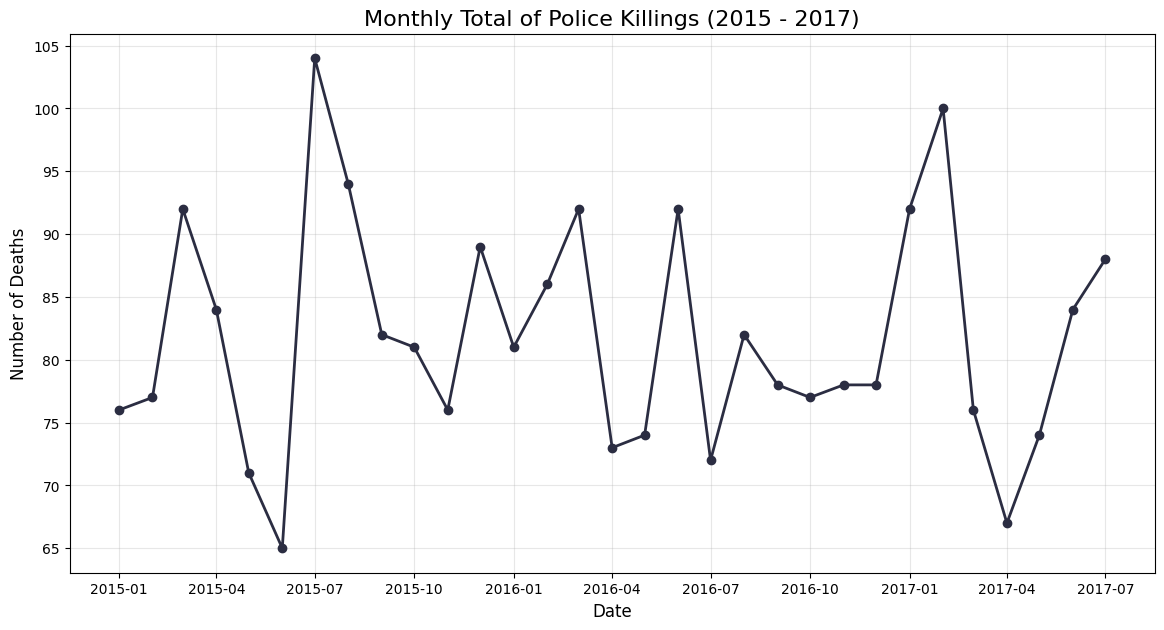

In [55]:
temp_dates = pd.to_datetime(df_fatalities['date'], dayfirst=True)

df_monthly_killings = temp_dates.dt.to_period('M').value_counts().sort_index()

df_monthly_killings.index = df_monthly_killings.index.to_timestamp()

plt.figure(figsize=(14, 7))
plt.plot(df_monthly_killings.index, df_monthly_killings.values, marker='o', linestyle='-', color='#2b2d42', linewidth=2)

plt.title('Monthly Total of Police Killings (2015 - 2017)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).